In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

from scipy.sparse import vstack, load_npz
from sklearn.preprocessing import StandardScaler
import sklearn.metrics as skm
import sklearn.utils as sku

import torch as pt
import torch.nn as nn
import torch.optim as optim

from torch.nn import CrossEntropyLoss
from torch.utils.data import Dataset, DataLoader

import optuna as opt

import Basic_functions as bf

from torchao.sparsity.training import (
    SemiSparseLinear,
    SemiSparseActivationLinear,
    swap_linear_with_semi_sparse_linear,
    swap_semi_sparse_linear_with_linear,
)

# Optional imports
# from torch.nn import L1Loss
# from scipy.special import expit

W0606 00:46:24.272000 36441 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [2]:
import numpy as np
from scipy import sparse
from scipy.sparse import load_npz
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import sklearn.utils as sku

# --------------------------------------------------------
# FILE IDS TO LOAD
# --------------------------------------------------------

file_ids = [
    "00",
    "01",
    "02",
    "03",
    "04",
    "05",
    "06",
    "07",
    "08",
    "09",
    "10",
    "11",
    "12",
    "13",
    "14",
    "15",
    "16",
    "17",
    "18"
]

# --------------------------------------------------------
# LOAD ARTICLE MATRICES
# --------------------------------------------------------

data_list = [
    load_npz(f"Data_files/data_articles_{fid}.npz")
    for fid in file_ids
]

# --------------------------------------------------------
# LOAD LABEL FILES
# --------------------------------------------------------

label_list = [
    np.genfromtxt(
        f"Data_files/labels_articles_{fid}.txt",
        delimiter="; ",
        dtype=str,
        encoding="latin1"
    )
    for fid in file_ids
]

# --------------------------------------------------------
# CREATE COMBINED DATASET
# --------------------------------------------------------

data_articles_all = sparse.vstack(
    data_list,
    format="csr"
)

labels_articles_all = np.vstack(
    label_list
)

assert data_articles_all.shape[0] == labels_articles_all.shape[0]

print("Initial data shape:", data_articles_all.shape)
print("Initial number of labels:", labels_articles_all.shape[0])

# --------------------------------------------------------
# LABEL COLUMN STRUCTURE
# --------------------------------------------------------
# index = 0 -> date
# index = 1 -> sermon or not
# index = 2 -> article title
# index = 3 -> article topic
# index = 4 -> lix score
# --------------------------------------------------------

# --------------------------------------------------------
# KEEP ONLY TOP X MOST FREQUENT TOPICS
# --------------------------------------------------------

top_x = 10

topics = labels_articles_all[:, 3]

unique_topics, topic_counts = np.unique(
    topics,
    return_counts=True
)

sorted_indices = np.argsort(topic_counts)[::-1]

valid_topics = unique_topics[
    sorted_indices[:top_x]
]

keep_mask = np.isin(
    topics,
    valid_topics
)

print("Original number of articles:", data_articles_all.shape[0])
print("Filtered number of articles:", keep_mask.sum())
print("Removed articles:", data_articles_all.shape[0] - keep_mask.sum())

print("\nTop topics kept:")
for topic in valid_topics:
    count = np.sum(topics == topic)
    print(f"{topic}: {count}")

data_articles_all = data_articles_all[keep_mask]
labels_articles_all = labels_articles_all[keep_mask]

assert data_articles_all.shape[0] == labels_articles_all.shape[0]

# --------------------------------------------------------
# SHUFFLE DATA AND LABELS
# --------------------------------------------------------

data_articles_all, labels_articles_all = sku.shuffle(
    data_articles_all,
    labels_articles_all,
    random_state=5466542
)

# --------------------------------------------------------
# SORT COLUMNS AND KEEP FIRST 251 FEATURES
# --------------------------------------------------------

sort_idx = np.genfromtxt(
    "txt_files/multiclass_sort_idx.txt",
    delimiter="\n",
    dtype=int
)

data_articles_all = data_articles_all[:, sort_idx][:, :3000]

print("Shape after column sorting/top 251:", data_articles_all.shape)

# --------------------------------------------------------
# ADD LIX SCORE AS FIRST COLUMN
# --------------------------------------------------------

lix_scores = labels_articles_all[:, 4].astype(np.float32)

assert data_articles_all.shape[0] == len(lix_scores)

lix_column = sparse.csr_matrix(
    lix_scores.reshape(-1, 1)
)

data_articles_all = sparse.hstack(
    [lix_column, data_articles_all],
    format="csr"
)

# --------------------------------------------------------
# SCALE FEATURES
# --------------------------------------------------------

scaler = StandardScaler(
    with_mean=False
)

data_articles_all = scaler.fit_transform(
    data_articles_all
)

# --------------------------------------------------------
# CONVERT TOPICS TO INTEGER LABELS
# --------------------------------------------------------

topic_labels = labels_articles_all[:, 3]

label_encoder = LabelEncoder()

topic_labels_encoded = label_encoder.fit_transform(
    topic_labels
)

# --------------------------------------------------------
# SPLIT DATA INTO TRAIN, VAL, TEST SETS
# --------------------------------------------------------

data_train, data_train_labels, data_val, data_val_labels, data_test, data_test_labels = bf.train_val_test_split(
    data_articles_all,
    topic_labels_encoded,
    val_size=0.20,
    test_size=0
)

# --------------------------------------------------------
# FINAL OUTPUT
# --------------------------------------------------------

print("\nFinal data shape:", data_articles_all.shape)
print("Final number of labels:", labels_articles_all.shape[0])

print("\nExample feature row:")
print(data_articles_all[0])

print("\nExample label row:")
print(labels_articles_all[0])

Initial data shape: (853077, 27000)
Initial number of labels: 853077
Original number of articles: 853077
Filtered number of articles: 504327
Removed articles: 348750

Top topics kept:
Danmark: 150348
Internationalt: 144647
Sport: 42216
Kultur: 35301
Politik: 34656
Økonomi: 30938
Fodbold: 27503
Forbrug: 13721
Film og tv: 13120
Cykling: 11877
Shape after column sorting/top 251: (504327, 3000)

Final data shape: (504327, 3001)
Final number of labels: 504327

Example feature row:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 145 stored elements and shape (1, 3001)>
  Coords	Values
  (0, 0)	7.266957653619334
  (0, 386)	3.203844547797791
  (0, 302)	6.64640962323575
  (0, 278)	1.6651791323057545
  (0, 732)	3.479544869491937
  (0, 109)	1.0523278483934069
  (0, 562)	1.454079395625171
  (0, 453)	4.514953380418077
  (0, 1418)	4.865402265974928
  (0, 264)	2.8982342142317497
  (0, 186)	1.7048570906218454
  (0, 230)	0.9611882712334866
  (0, 1044)	3.991882330151927
  (0, 613)	2.109865

# Functions

In [3]:
class MyDataset(Dataset):    
    def __init__(self, X_data, y_data):
        self.input = X_data
        self.truth = y_data
        
    def __getitem__(self, index):
        return self.input[index], self.truth[index]
        
    def __len__ (self):
        return self.truth.shape[0]

#In pytorch, there is an additional step of turning your data into tensors
train_data = MyDataset(data_train, data_train_labels)
val_data = MyDataset(data_val, data_val_labels)

In [4]:
# Training loop:
def Train(model, optimizer, loss_function, train_loader, validation_loader, device, epochs):
    validation_loss = []
    training_loss   = []
    model.train()
    for e in range(0, epochs):
        epoch_loss = 0
        n_minibatches = 0
        for input_train_batch, truth_train_batch in train_loader:
            input_train_batch, truth_train_batch = input_train_batch.to(device), truth_train_batch.to(device)
            optimizer.zero_grad()
            prediction = model(input_train_batch)  # This asks our model to produce predictions on the training batch            
            loss = loss_function(prediction, truth_train_batch.long())  # This calculates the loss
            loss.backward()                                             # This initiates the backpropagation
            optimizer.step()
            epoch_loss += loss.item()
            n_minibatches += 1
        
        # Now that the model have trained 1 epoch, we evaluate the model on the validation set:
        valid_loss = Validate(model, validation_loader, device, loss_function)
        validation_loss.append(valid_loss)
        training_loss.append(epoch_loss/n_minibatches)
        print('EPOCH: %s | training loss: %s  | validation loss: %s'%(e+1,round(epoch_loss/n_minibatches,3), round(valid_loss, 3)))
    return training_loss, validation_loss


def Validate(model, validation_loader, device, loss_function):
    model.eval()
    n_batches  = 0
    validation_loss = 0
    with pt.no_grad():
        for input_valid_batch, truth_valid_batch in validation_loader:
            input_valid_batch, truth_valid_batch = input_valid_batch.to(device), truth_valid_batch.to(device)
            prediction = model(input_valid_batch)
            loss = loss_function(prediction, truth_valid_batch.long())
            validation_loss += loss.item()
            n_batches += 1
    validation_loss = validation_loss/n_batches
    return validation_loss


def Predict(model, prediction_loader, device):
    model.eval()
    predictions = []
    print('PREDICTING!')
    with pt.no_grad():
        for input_pred_batch, _ in prediction_loader:
            input_pred_batch = input_pred_batch.to(device)
            prediction = model(input_pred_batch)
            predictions.extend(prediction.numpy())
    print('Done Predicting!')
    return predictions
                
class MeanRelativeAbsoluteDeviationLoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps
                
    def forward(self, prediction, target):
        prediction = prediction.view_as(target)
        relative_absolute_error = pt.abs(prediction - target) / (pt.abs(target) + self.eps)
        return pt.mean(relative_absolute_error)

In [5]:
def sparse_collate(batch):
    xs, ys = zip(*batch)

    first = xs[0]
    n_features = first.shape[-1]

    batch_rows = []
    batch_cols = []
    batch_vals = []

    for i, x in enumerate(xs):
        x = x.tocoo()
        batch_rows.append(np.full_like(x.col, i, dtype=np.int64))
        batch_cols.append(x.col.astype(np.int64))
        batch_vals.append(x.data.astype(np.float32))

    indices = pt.tensor(
        np.vstack([np.concatenate(batch_rows), np.concatenate(batch_cols)]),
        dtype=pt.long
    )
    values = pt.tensor(np.concatenate(batch_vals), dtype=pt.float32)

    X = pt.sparse_coo_tensor(indices, values, size=(len(xs), n_features)).coalesce()
    y = pt.tensor(np.asarray(ys), dtype=pt.long)
    return X, y

In [6]:
def objective(trial):

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-5,
        1e-2,
        log=True
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [32, 64, 128]
    )

    Layer1 = trial.suggest_int("Layer1", 64, 256)
    Layer2 = trial.suggest_int("Layer2", 32, 128)
    Layer3 = trial.suggest_int("Layer3", 8, 64)

    dropout_rate = trial.suggest_float(
        "dropout_rate",
        0.1,
        0.5
    )

    n_epochs = 10

    input_dim = data_train.shape[1]
    num_classes = len(label_encoder.classes_)

    class OptModel(nn.Module):

        def __init__(self):
            super(OptModel, self).__init__()

            self.input_layer = nn.Linear(input_dim, Layer1)
            self.hidden_layer1 = nn.Linear(Layer1, Layer2)
            self.hidden_layer2 = nn.Linear(Layer2, Layer3)
            self.output_layer = nn.Linear(Layer3, num_classes)

            self.relu = nn.ReLU()
            self.dropout = nn.Dropout(dropout_rate)

        def forward(self, inputs):

            x = self.input_layer(inputs)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.hidden_layer1(x)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.hidden_layer2(x)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.output_layer(x)

            return x

    device = pt.device(
        "cuda" if pt.cuda.is_available() else "cpu"
    )

    model_opt = OptModel().to(device)

    loss_function = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model_opt.parameters(),
        lr=learning_rate,
        weight_decay=1e-4
    )

    train_loader = DataLoader(
        dataset=train_data,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=sparse_collate
    )

    validation_loader = DataLoader(
        dataset=val_data,
        batch_size=batch_size,
        collate_fn=sparse_collate
    )

    best_validation_loss = float("inf")

    for epoch in range(n_epochs):

        print(f"Trial {trial.number} | Optuna epoch {epoch + 1}/{n_epochs}")

        training_loss, validation_loss = Train(
            model_opt,
            optimizer,
            loss_function,
            train_loader,
            validation_loader,
            device,
            1)

        current_validation_loss = validation_loss[-1]

        best_validation_loss = min(
            best_validation_loss,
            current_validation_loss
        )

        trial.report(current_validation_loss, epoch)

        if trial.should_prune():
            raise opt.exceptions.TrialPruned()

    return best_validation_loss

# HP optimization

In [7]:
pruner = opt.pruners.MedianPruner(
    n_startup_trials=2,
    n_warmup_steps=1
)

study = opt.create_study(
    direction="minimize",
    pruner=pruner
)

study.optimize(
    objective,
    n_trials=30
)

print("Best trial:")
print(study.best_trial)

print("Best parameters:")
print(study.best_trial.params)

[I 2026-06-06 00:47:11,874] A new study created in memory with name: no-name-088c5ca3-f3fa-4cef-83c3-e1fe67e0e2d4


Trial 0 | Optuna epoch 1/10


/var/folders/rp/p2_g6d3j74ggpl15kr0_k5zc0000gn/T/ipykernel_36441/936182257.py:23: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  X = pt.sparse_coo_tensor(indices, values, size=(len(xs), n_features)).coalesce()


EPOCH: 1 | training loss: 0.809  | validation loss: 0.676
Trial 0 | Optuna epoch 2/10
EPOCH: 1 | training loss: 0.71  | validation loss: 0.657
Trial 0 | Optuna epoch 3/10
EPOCH: 1 | training loss: 0.687  | validation loss: 0.654
Trial 0 | Optuna epoch 4/10
EPOCH: 1 | training loss: 0.677  | validation loss: 0.646
Trial 0 | Optuna epoch 5/10
EPOCH: 1 | training loss: 0.668  | validation loss: 0.651
Trial 0 | Optuna epoch 6/10
EPOCH: 1 | training loss: 0.664  | validation loss: 0.646
Trial 0 | Optuna epoch 7/10
EPOCH: 1 | training loss: 0.662  | validation loss: 0.643
Trial 0 | Optuna epoch 8/10
EPOCH: 1 | training loss: 0.659  | validation loss: 0.64
Trial 0 | Optuna epoch 9/10
EPOCH: 1 | training loss: 0.655  | validation loss: 0.64
Trial 0 | Optuna epoch 10/10


[I 2026-06-06 01:08:43,113] Trial 0 finished with value: 0.6374834328759881 and parameters: {'learning_rate': 0.0008869984756490663, 'batch_size': 32, 'Layer1': 69, 'Layer2': 101, 'Layer3': 26, 'dropout_rate': 0.17768067372965254}. Best is trial 0 with value: 0.6374834328759881.


...

EPOCH: 1 | training loss: 0.68  | validation loss: 0.625
Trial 28 | Optuna epoch 1/10
EPOCH: 1 | training loss: 0.735  | validation loss: 0.627
Trial 28 | Optuna epoch 2/10
EPOCH: 1 | training loss: 0.608  | validation loss: 0.61
Trial 28 | Optuna epoch 3/10
EPOCH: 1 | training loss: 0.552  | validation loss: 0.604
Trial 28 | Optuna epoch 4/10


[I 2026-06-06 05:04:03,982] Trial 28 pruned. 


EPOCH: 1 | training loss: 0.511  | validation loss: 0.602
Trial 29 | Optuna epoch 1/10
EPOCH: 1 | training loss: 0.794  | validation loss: 0.662
Trial 29 | Optuna epoch 2/10


[I 2026-06-06 05:08:02,925] Trial 29 pruned. 


EPOCH: 1 | training loss: 0.692  | validation loss: 0.641
Best trial:
FrozenTrial(number=21, state=<TrialState.COMPLETE: 1>, values=[0.5919874159524131], datetime_start=datetime.datetime(2026, 6, 6, 4, 9, 13, 643529), datetime_complete=datetime.datetime(2026, 6, 6, 4, 23, 55, 859710), params={'learning_rate': 0.00017559841631289443, 'batch_size': 64, 'Layer1': 245, 'Layer2': 81, 'Layer3': 60, 'dropout_rate': 0.19597097233905492}, user_attrs={}, system_attrs={}, intermediate_values={0: 0.6399115036698217, 1: 0.6101835587563332, 2: 0.5956142492820884, 3: 0.5919874159524131, 4: 0.6014207728096675, 5: 0.6011721712880229, 6: 0.6158053704295909, 7: 0.6187884944187537, 8: 0.6365131339571777, 9: 0.6473836491493297}, distributions={'learning_rate': FloatDistribution(high=0.01, log=True, low=1e-05, step=None), 'batch_size': CategoricalDistribution(choices=(32, 64, 128)), 'Layer1': IntDistribution(high=256, log=False, low=64, step=1), 'Layer2': IntDistribution(high=128, log=False, low=32, step=1)

In [8]:
print(study.best_trial.params)

{'learning_rate': 0.00017559841631289443, 'batch_size': 64, 'Layer1': 245, 'Layer2': 81, 'Layer3': 60, 'dropout_rate': 0.19597097233905492}


# Split data for actual training

In [9]:
# --------------------------------------------------------
# split data into train, val, test sets
# --------------------------------------------------------

data_train, data_train_labels, data_val, data_val_labels, data_test, data_test_labels = bf.train_val_test_split(
    data_articles_all,
    topic_labels_encoded,
    val_size=0.20,
    test_size=0.1
)

train_data = MyDataset(data_train, data_train_labels)
val_data = MyDataset(data_val, data_val_labels)
test_data = MyDataset(data_test, data_test_labels)

# Train the data with HP optimized parameters

In [10]:
best_params = study.best_trial.params

learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]

Layer1 = best_params["Layer1"]
Layer2 = best_params["Layer2"]
Layer3 = best_params["Layer3"]

dropout_rate = best_params["dropout_rate"]

n_epochs = 3

input_dim = data_train.shape[1]
num_classes = len(label_encoder.classes_)

print("Starting setup...")
print("Best hyperparameters:", best_params)
print("Input dimension:", input_dim)
print("Number of classes:", num_classes)

class TopicModel(nn.Module):

    def __init__(self):
        super(TopicModel, self).__init__()

        self.input_layer = nn.Linear(input_dim, Layer1)
        self.hidden_layer1 = nn.Linear(Layer1, Layer2)
        self.hidden_layer2 = nn.Linear(Layer2, Layer3)
        self.output_layer = nn.Linear(Layer3, num_classes)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, inputs):

        x = self.input_layer(inputs)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.hidden_layer1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.hidden_layer2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.output_layer(x)

        return x

print("Selecting device...")
device = pt.device("cuda" if pt.cuda.is_available() else "cpu")
print("Using device:", device)

print("Creating model...")
model = TopicModel().to(device)
print("Model created.")

print("Creating optimizer...")
optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=1e-4
)
print("Optimizer created.")

print("Creating loss function...")
loss_function = CrossEntropyLoss()
print("Loss function created.")

print("Creating data loaders...")
train_loader = DataLoader(
    dataset=train_data,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=sparse_collate
)

validation_loader = DataLoader(
    dataset=val_data,
    batch_size=batch_size,
    collate_fn=sparse_collate
)

print("Data loaders created.")
print("Starting training...")

training_loss, validation_loss = Train(
    model,
    optimizer,
    loss_function,
    train_loader,
    validation_loader,
    device,
    n_epochs
)

print("Training finished.")
print("Training losses:")
print(training_loss)

print("Validation losses:")
print(validation_loss)

Starting setup...
Best hyperparameters: {'learning_rate': 0.00017559841631289443, 'batch_size': 64, 'Layer1': 245, 'Layer2': 81, 'Layer3': 60, 'dropout_rate': 0.19597097233905492}
Input dimension: 3001
Number of classes: 10
Selecting device...
Using device: cpu
Creating model...
Model created.
Creating optimizer...
Optimizer created.
Creating loss function...
Loss function created.
Creating data loaders...
Data loaders created.
Starting training...
EPOCH: 1 | training loss: 0.804  | validation loss: 0.643
EPOCH: 2 | training loss: 0.586  | validation loss: 0.6
EPOCH: 3 | training loss: 0.504  | validation loss: 0.595
Training finished.
Training losses:
[0.8038907400211692, 0.5861774392970256, 0.5040990851653406]
Validation losses:
[0.6434143784685685, 0.5998597177443583, 0.5948464350187862]


# Plotting the results

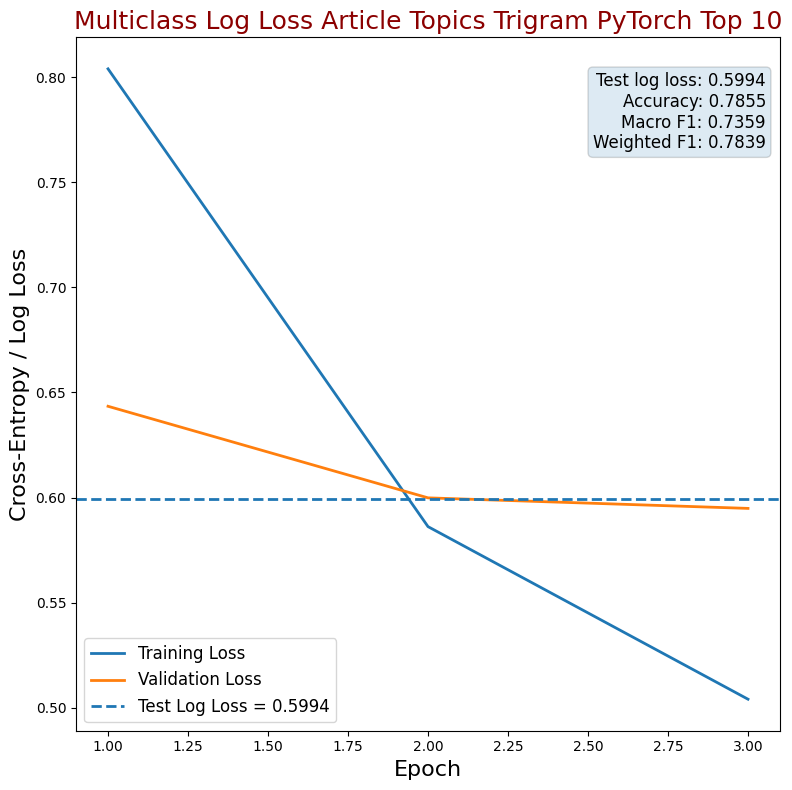


FINAL TEST RESULTS
Cross-Entropy Loss : 0.5995
Log Loss           : 0.5994
Accuracy           : 0.7855
Macro F1           : 0.7359
Weighted F1        : 0.7839


In [14]:
# --------------------------------------------------------
# TEST / VALIDATION SET EVALUATION
# --------------------------------------------------------

test_loader = DataLoader(
    dataset=test_data,
    batch_size=batch_size,
    collate_fn=sparse_collate
)

model.eval()

all_probabilities = []
all_predictions = []
all_truths = []

test_loss = 0.0
n_batches = 0

with pt.no_grad():

    for input_batch, truth_batch in test_loader:

        input_batch = input_batch.to(device)
        truth_batch = truth_batch.to(device)

        outputs = model(input_batch)

        loss = loss_function(
            outputs,
            truth_batch.long()
        )

        test_loss += loss.item()
        n_batches += 1

        probabilities = pt.softmax(outputs, dim=1)
        predictions = pt.argmax(outputs, dim=1)

        all_probabilities.extend(probabilities.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_truths.extend(truth_batch.cpu().numpy())

all_probabilities = np.array(all_probabilities)
all_predictions = np.array(all_predictions)
all_truths = np.array(all_truths)

final_test_loss = test_loss / n_batches

final_log_loss = log_loss(
    all_truths,
    all_probabilities
)

test_accuracy = accuracy_score(
    all_truths,
    all_predictions
)

macro_f1 = f1_score(
    all_truths,
    all_predictions,
    average="macro"
)

weighted_f1 = f1_score(
    all_truths,
    all_predictions,
    average="weighted"
)

# --------------------------------------------------------
# LOSS CURVE WITH FINAL LOG LOSS DISPLAYED
# --------------------------------------------------------

epochs = np.arange(1, len(training_loss) + 1)

plt.figure(figsize=(8, 8))

plt.plot(
    epochs,
    training_loss,
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    epochs,
    validation_loss,
    linewidth=2,
    label="Validation Loss"
)

plt.axhline(
    final_log_loss,
    linestyle="--",
    linewidth=2,
    label=f"Test Log Loss = {final_log_loss:.4f}"
)

plt.text(
    0.98,
    0.95,
    f"Test log loss: {final_log_loss:.4f}\n"
    f"Accuracy: {test_accuracy:.4f}\n"
    f"Macro F1: {macro_f1:.4f}\n"
    f"Weighted F1: {weighted_f1:.4f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round", alpha=0.15)
)

plt.xlabel("Epoch", fontsize=16)
plt.ylabel("Cross-Entropy / Log Loss", fontsize=16)

plt.title(
    "Multiclass Log Loss Article Topics Trigram PyTorch Top 10",
    fontsize=18,
    color="darkred"
)

plt.legend(fontsize=12)
plt.tight_layout()

plt.savefig(
    "Multiclass_LogLoss_ArticleTopics_TrigramPytorch_Top10.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

# --------------------------------------------------------
# REPORT RESULTS
# --------------------------------------------------------

print("\n" + "=" * 50)
print("FINAL TEST RESULTS")
print("=" * 50)
print(f"Cross-Entropy Loss : {final_test_loss:.4f}")
print(f"Log Loss           : {final_log_loss:.4f}")
print(f"Accuracy           : {test_accuracy:.4f}")
print(f"Macro F1           : {macro_f1:.4f}")
print(f"Weighted F1        : {weighted_f1:.4f}")
print("=" * 50)

Generating test predictions...


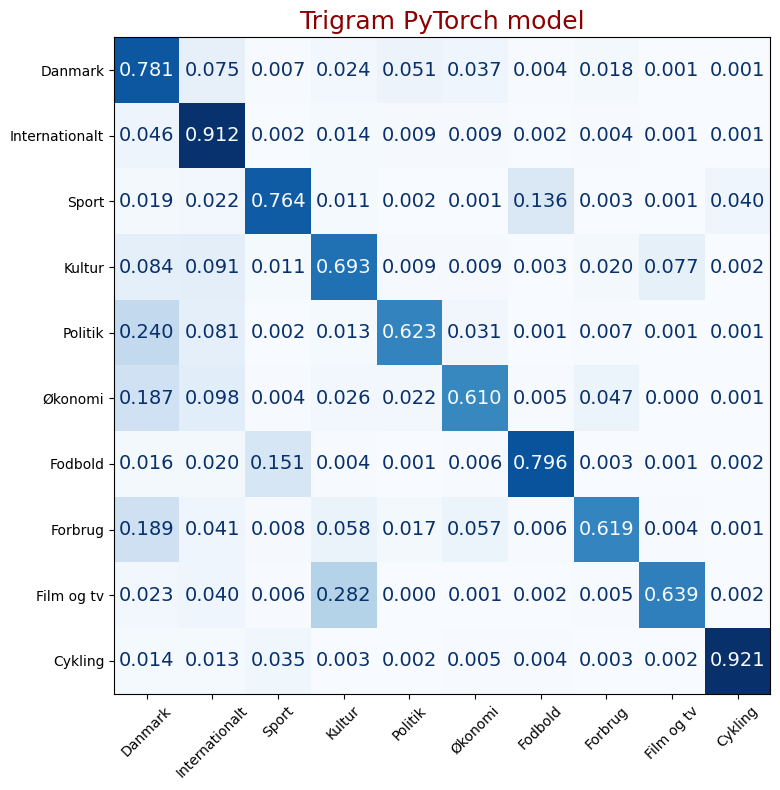

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------------
# GET TEST PREDICTIONS
# --------------------------------------------------------

model.eval()

all_predictions = []
all_truths = []

print("Generating test predictions...")

with pt.no_grad():

    for input_batch, truth_batch in test_loader:

        input_batch = input_batch.to(device)

        outputs = model(input_batch)
        predictions = pt.argmax(outputs, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_truths.extend(truth_batch.cpu().numpy())

# --------------------------------------------------------
# DEFINE DESIRED TOPIC ORDER
# --------------------------------------------------------

desired_order = [
    "Danmark",
    "Internationalt",
    "Sport",
    "Kultur",
    "Politik",
    "Økonomi",
    "Fodbold",
    "Forbrug",
    "Film og tv",
    "Cykling"
]

# Convert topic names to encoded integer labels
label_order = label_encoder.transform(desired_order)

# --------------------------------------------------------
# NORMALIZED CONFUSION MATRIX
# --------------------------------------------------------

cm = confusion_matrix(
    all_truths,
    all_predictions,
    labels=label_order,
    normalize="true"
)

cm = np.round(cm, 3)

# --------------------------------------------------------
# PLOT CONFUSION MATRIX
# --------------------------------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=desired_order
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap=plt.cm.Blues,
    colorbar=False,
    values_format=".3f"
)

ax.set_xlabel("")
ax.set_ylabel("")

for t in disp.text_.ravel():
    t.set_fontsize(14)

plt.title(
    "Trigram PyTorch model",
    fontsize=18,
    color="darkred"
)

plt.tight_layout()

plt.savefig(
    "confusion_matrix_multiclass_TrigramPytorch.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Generating test prediction probabilities...


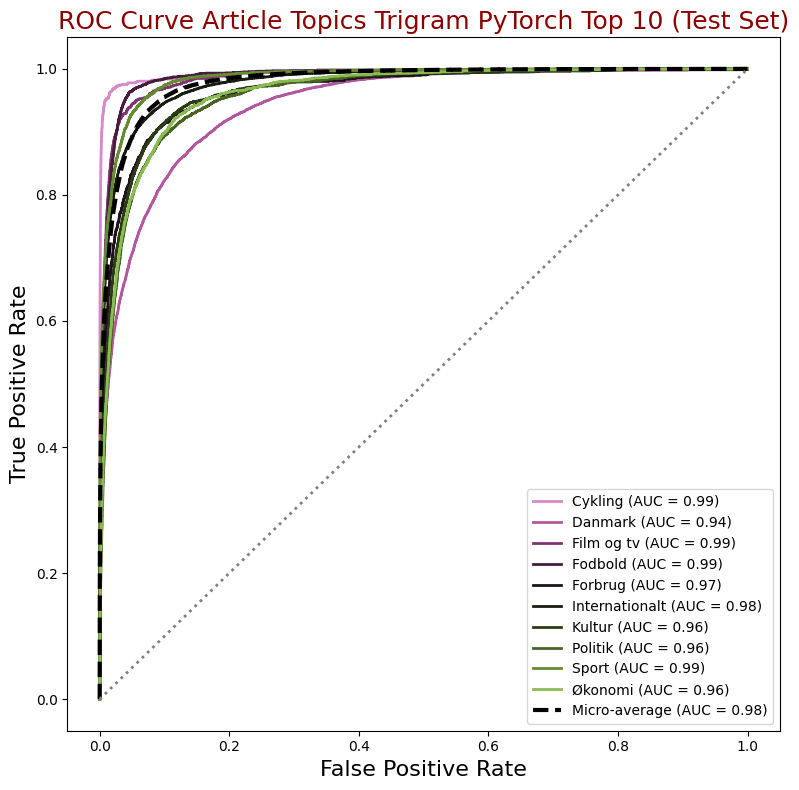

Micro-average AUC: 0.9794
Accuracy: 39616/50432 = 0.7855


In [36]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------------
# GET TEST PROBABILITIES AND PREDICTIONS
# --------------------------------------------------------

model.eval()

all_probabilities = []
all_predictions = []
all_truths = []

print("Generating test prediction probabilities...")

with pt.no_grad():

    for input_batch, truth_batch in test_loader:

        input_batch = input_batch.to(device)

        outputs = model(input_batch)

        probabilities = pt.softmax(outputs, dim=1)
        predictions = pt.argmax(outputs, dim=1)

        all_probabilities.extend(probabilities.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_truths.extend(truth_batch.cpu().numpy())

all_probabilities = np.array(all_probabilities)
all_predictions = np.array(all_predictions)
all_truths = np.array(all_truths)

# --------------------------------------------------------
# ACCURACY
# --------------------------------------------------------

correct_guesses = np.sum(all_predictions == all_truths)
total_datapoints = len(all_truths)
accuracy = correct_guesses / total_datapoints

# --------------------------------------------------------
# BINARIZE LABELS
# --------------------------------------------------------

classes = label_encoder.classes_
num_classes = len(classes)

truths_binarized = label_binarize(
    all_truths,
    classes=np.arange(num_classes)
)

# --------------------------------------------------------
# ROC CURVES
# --------------------------------------------------------

fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):

    fpr[i], tpr[i], _ = roc_curve(
        truths_binarized[:, i],
        all_probabilities[:, i]
    )

    roc_auc[i] = auc(fpr[i], tpr[i])

# --------------------------------------------------------
# MICRO AVERAGE
# --------------------------------------------------------

fpr["micro"], tpr["micro"], _ = roc_curve(
    truths_binarized.ravel(),
    all_probabilities.ravel()
)

roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# --------------------------------------------------------
# COLORS
# --------------------------------------------------------

cmap = plt.get_cmap("vanimo")

colors = cmap(
    np.linspace(0.1, 0.9, num_classes)
)

# --------------------------------------------------------
# PLOT
# --------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 8))

for i, color in zip(range(num_classes), colors):

    ax.plot(
        fpr[i],
        tpr[i],
        color=color,
        linewidth=2,
        label=f"{classes[i]} (AUC = {roc_auc[i]:.2f})"
    )

ax.plot(
    fpr["micro"],
    tpr["micro"],
    color="black",
    linestyle="--",
    linewidth=3,
    label=f"Micro-average (AUC = {roc_auc['micro']:.2f})"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle=":",
    linewidth=2,
    color="gray"
)

plt.title(
    "ROC Curve Article Topics Trigram PyTorch Top 10 (Test Set)",
    fontsize=18,
    color="darkred"
)

plt.xlabel("False Positive Rate", fontsize=16)
plt.ylabel("True Positive Rate", fontsize=16)

plt.legend(fontsize=10, loc="lower right")

plt.tight_layout()

plt.savefig(
    "Multiclass_ROC_ArticleTopics_TrigramPytorch_Top10_TEST.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

# --------------------------------------------------------
# PRINT RESULTS
# --------------------------------------------------------

print(f"Micro-average AUC: {roc_auc['micro']:.4f}")
print(f"Accuracy: {correct_guesses}/{total_datapoints} = {accuracy:.4f}")